# 4.1. 로지스틱 회귀

럭키백에 생선을 담아 담긴 생선의 확률을 알려주는 이벤트를 기획하였다. 어떻게 하면 럭키백에 담긴 생선의 특성들을 바탕으로 어떤 생선일지 알려주는 확률을 보여줄 수 있을까?

In [7]:
# 최근접 이웃 분류기처럼 클래스 확률을 계산해보자.

import pandas as pd

fish = pd.read_csv('https://bit.ly/fish_csv_data')
print(fish.head())
print(fish)

  Species  Weight  Length  Diagonal   Height   Width
0   Bream   242.0    25.4      30.0  11.5200  4.0200
1   Bream   290.0    26.3      31.2  12.4800  4.3056
2   Bream   340.0    26.5      31.1  12.3778  4.6961
3   Bream   363.0    29.0      33.5  12.7300  4.4555
4   Bream   430.0    29.0      34.0  12.4440  5.1340
    Species  Weight  Length  Diagonal   Height   Width
0     Bream   242.0    25.4      30.0  11.5200  4.0200
1     Bream   290.0    26.3      31.2  12.4800  4.3056
2     Bream   340.0    26.5      31.1  12.3778  4.6961
3     Bream   363.0    29.0      33.5  12.7300  4.4555
4     Bream   430.0    29.0      34.0  12.4440  5.1340
..      ...     ...     ...       ...      ...     ...
154   Smelt    12.2    12.2      13.4   2.0904  1.3936
155   Smelt    13.4    12.4      13.5   2.4300  1.2690
156   Smelt    12.2    13.0      13.8   2.2770  1.2558
157   Smelt    19.7    14.3      15.2   2.8728  2.0672
158   Smelt    19.9    15.0      16.2   2.9322  1.8792

[159 rows x 6 columns

head()는 처음 5개 행을 출력해주는 함수다.

맨 왼쪽의 숫자 0~4는 판다스의 인덱스이고, Species ~ Width는 열 제목이다. 

판다스는 csv 파일의 첫 줄을 자동으로 인식해 열 제목으로 만들어 준다.

In [8]:
# 어떤 종류의 생선이 있는지, Species 열을 갖고 확인해보자.

print(pd.unique(fish['Species']))

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


In [9]:
# 여기서 Species를 타겟 데이터로 삼고, 나머지 열을 속성으로 활용한다.

fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
print(fish_input[:5])
# 뽑아낼 열들을 리스트로 인덱스를 전달한다는 것에 유의.

[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]]


In [10]:
# 이제 타겟 데이터를 뽑아보자.

fish_target = fish['Species'].to_numpy()
print(fish_target[:5])

['Bream' 'Bream' 'Bream' 'Bream' 'Bream']


In [11]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

In [12]:
# 학습,테스트 인풋의 스케일 정규화. (무게, 길이, 대각선길이, 높이, 너비)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_input) # 속성들의 평균/표준편차를 계산
train_scaled = scaler.transform(train_input)
test_scaled = scaler.transform(test_input)

정규화된 데이터와 타겟 데이터가 준비되었으니, K-최근접 이웃 분류기로 테스트 세트에 들어있는 확률을 예측해보자.

In [13]:
# K-최근접 이웃 분류기의 확률 예측

from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


분류 문제이면서 2개 이상의 클래스가 타겟 데이터에 포함되어 있는 문제를 '다중 분류'(multi-class classification) 문제라고 한다.

사이킷 런에서는 타겟 값을 숫자로 입력하지 않아도 문자열 로 된 타겟값을 그대로 사용할 수 있다.

또한 타겟값을 그대로 모델에 전달하면 순서가 자동으로 알파벳 순서로 매겨지니 주의해야 한다.

In [14]:
# 알파벳 순으로 정렬된 타겟값
print(kn.classes_)

# Bream이 첫 번째 클래스, Parkki가 두 번째 클래스가 되는 식이다.

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [15]:
print(test_input[:5])
#print(test_scaled[:5])
print(kn.predict(test_scaled[:5]))

[[ 78.      18.7     19.4      5.1992   3.1234]
 [ 13.4     12.4     13.5      2.43     1.269 ]
 [200.      32.3     34.8      5.568    3.3756]
 [270.      26.      28.7      8.3804   4.2476]
 [150.      23.      24.5      5.2185   3.626 ]]
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']


In [16]:
# 이 테스트 샘플에 대한 예측은 어떻게 만들어진 것일까?
# 사이킷 런의 분류 모델은 predict_proba() 메서드로, 속성별 확률값을 반환한다.

# numpy의 round()함수는 디폴트로 소수점 첫째 자리에서 반올림을 하는데, decimals 매개변수로 유지할 소수점 아래 자릿수를 지정할 수 있다.
import numpy as np

proba = kn.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=4))

[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


predict_proba() 메서드의 출력 순서는 앞서 보았던 classes_ 속성과 같다.

이 모델이 계산한 확률이 가장 가까운 이웃의 비율이 맞는지 확인해보자. 네 번째 샘플의 최근접 이웃의 클래스를 확인해보자.

In [17]:
distances, indexes = kn.kneighbors(test_scaled[3:4]) #  입력이 2차원 배열이어야 하므로 슬라이싱으로 전달함. [3]로 하면 1차원 배열이라 안됨.
print(train_target[indexes])
# 모델.kneighbors 는 인풋의 가장 가까운 이웃 샘플에 대한 거리/인덱스를 전달하고, 훈련 세트의 인풋/타겟에 전달해 어떤 데이터인지 확인 가능하다.!!!

[['Roach' 'Perch' 'Perch']]


# 로지스틱 회귀

3개의 최근접 이웃을 사용하기 때문에, 가능한 확률은 0, 1/3, 2/3, 1 밖에 없다.

만약 럭키백의 확률을 이렇게만 표시한다면 마케팅 팀이 만족스럽지 않을 것 같다. 뭔가 더 좋은 방법이 없을까?

로지스틱 회귀 (Logistic Regression)는 이름은 회귀지만, 분류 모델이다. 이 알고리즘은 선형 회귀와 동일하게 선형 방정식을 학습한다.
예를 들면, 

z = a X (Weight) + b X (Length) + c X (Diagonal) + d X (Height) + e X (Width) + f

여기에서 a, b, c, d, e는 가중치 혹은 계수이다. 특성은 늘어났지만 3장에서 다룬 다중 회귀를 위한 선형 방정식과 같다.

**z는 어떤 값도 가능하다. 하지만 확률이 되려면 0~1 사이 값이 되어야 한다. z가 아주 큰 음수일 때 0이 되고, 아주 큰 양수일 때 1이 되도록 바꾸어야 하는데, 시그모이드 함수(sigmoid function) (또는 로지스틱 함수)를 사용하면 가능하다.**

> pi = 1 / (1 + e^(-z))

위 pi가 시그모이드 함수이다.

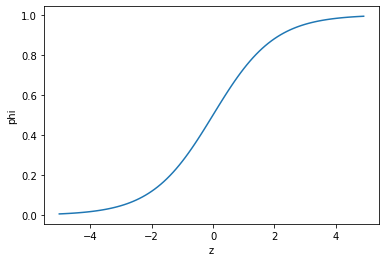

In [18]:
# sigmoid 함수를 그려보자
import numpy as np
import matplotlib.pyplot as plt

z = np.arange(-5, 5, 0.1)
phi = 1 / (1 + np.exp(-z))
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

In [19]:
# 사이킷런에는 이미 로지스틱 회귀 모델인 LogisticRegression 클래스가 준비되어있다.
# 먼저 간단하게 이진 분류를 수행해보자.

# numpy 배열은 True, False배열을 전달하여 행을 선택할 수 있다. 이를 불리언 인덱싱이라고 한다.
char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
print(char_arr[[True, False, True, False, False]])
# 이 방식을 활용해서 도미(Bream)와 빙어(Smelt)행만 골라내보자.

['A' 'C']


(참고) 사이킷 런은 0.5일 때 음성 클래스로 판단한다.

In [20]:
# 불리언 배열
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')

train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

In [21]:
# 로지스틱 회귀는 선형 모델이므로 sklearn.linear_model 패키지 아래 LogisticRegression 클래스가 존재한다.
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

LogisticRegression()

In [22]:
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [23]:
# KNeighborsClassifier 클래스와 같이 LogisticRegression 클래스도 predict_proba() 메서드로 예측 확률을 제공한다.
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99759855 0.00240145]
 [0.02735183 0.97264817]
 [0.99486072 0.00513928]
 [0.98584202 0.01415798]
 [0.99767269 0.00232731]]


In [24]:
# 위처럼 표시된 확률은 첫 번째 열이 음성 클래스(0)에 대한 확률이고, 두 번째 열이 양성 클래스(1)에 대한 확률이다.
# Bream과 Smelt중 어떤 것이 음성/양성 클래스일까?
# k-최근접 이웃 분류 모델에서 본 것처럼 lr.classes_ 속성으로 확인할 수 있다.

print(lr.classes_)

['Bream' 'Smelt']


In [25]:
# 그리고 이 로지스틱 회귀 모델이 학습한 계수, 절편은 어떤 값일까?

print("lr모델의 계수들: ", lr.coef_)
print("lr모델의 절편: ", lr.intercept_)

lr모델의 계수들:  [[-0.4037798  -0.57620209 -0.66280298 -1.01290277 -0.73168947]]
lr모델의 절편:  [-2.16155132]


즉, 이 lr모델이 학습한 방정식은

z = -0.4037798 X (Weight) -0.57620209 X (Length) -0.66280298 X (Diagonal) -1.01290277 (Height) -0.73168947(Width) - 2.16155132 이다.

확실히 로지스틱 회귀는 선형 회귀와 매우 비슷하다.

그럼 LogisticRegression 모델로 z 값을 계산해 볼 수 있을까? LogisticRegression 클래스는 decision_function() 메서드로 z값을 출력할 수 있다. train_bream_smelt의 처음 5개 샘플의 z값을 출력해보자.

In [26]:
decisions = lr.decision_function(train_bream_smelt[:5])
print(decisions)

[-6.02927744  3.57123907 -5.26568906 -4.24321775 -6.0607117 ]


In [27]:
# numpy의 exp(-z)로 시그모이드 함수를 구현하는 것보다 사이파이(scipy) 라이브러리의 expit 함수를 사용하자.
# 더욱 안전하고 편리하다.

from scipy.special import expit
print(expit(decisions))

[0.00240145 0.97264817 0.00513928 0.01415798 0.00232731]


출력된 값을 보면 [36]의 두 번째 열과 값이 동일한 것을 알 수 있다. 즉, decision_function()은 양성 클래스에 대한 z값을 반환한다.

즉, 정리하면 이진 분류를 연습해보기 위해,
1. 불리언 인덱싱을 활용해 두 개의 클래스에 대한 데이터들만 추출하고,
2. 이를 바탕으로 로지스틱 회귀 모델을 훈련한 뒤,
3. predict_proba 메서드로 음성/양성 클래스에 대한 확률(z값)을 출력해봤고,
4. decision_function 메서드로 양성 클래스에 대한 z값을 계산해보았다.
5. 또 coef_속성과 intercept_속성으로 로지스틱 회귀 모델이 학습한 선형 방정식의 계수와 절편도 확인할 수 있었다.

아래부터는 로지스틱 회귀로 '다중 분류'를 수행해보자.
로지스틱 회귀는 선형 모델과 유사하게 방정식을 학습하며 회귀보다 분류에 더 가깝다는 것을 기억하자.

# 로지스틱 회귀로 다중 분류 수행하기

앞서 이진 분류를 위해 로지스틱 회귀 모델을 훈련시켜 보았다.

다중 분류도 크게 다르지 않은데, 여기서도 LogisticRegression 클래스를 사용해 일곱 종류의 생선을 분류해 보면서 이진 분류와의 차이점을 알아보자.

LogisticRegression 클래스는 기본적으로 반복적인(iterative) 알고리즘을 사용한다. max_iter 매개변수에서 반복 횟수를 지정하며, 기본값은 100이다. 여기에 준비한 데이터 셋을 사용해 모델을 훈련하면 반복 횟수가 부족하다는 경고가 발생한다. 충분하게 훈련 시키기 위해 반복 횟수를 1000으로 늘려본다.

**또 LogisticRegression 은 기본적으로 릿지 회귀와 같이 계수의 제곱을 규제 (Regularization) 한다. 이런 규제를 L2 규제라고도 한다. 릿지 회귀에서는 alpha 매개변수로 규제의 양을 조절했다. alpha가 커지면 규제도 커진다. LogisticRegression에서 규제를 제어하는 매개변수는 C이다. 하지만 C는 alpha와 반대로 작을수록 규제가 커진다.** C의 기본값은 1이며, 여기서는 규제를 조금 완화하기 위해 20으로 늘린다.

In [31]:
lr = LogisticRegression(C=20, max_iter=1000) # C는 로지스틱 회귀에서 규제에 대한 하이퍼파라미터이며, 작을수록 규제가 커진다. 릿지의 alpha와 반대임.
# 7개의 생선 데이터가 모두 들어있는 train_scaled와 train_target을 사용하여 로지스틱 회귀로 '다중 분류(multiple classification)'를 수행한다.

lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

# 훈련세트, 테스트 세트 점수가 높고 과대/과소적합으로 치우친 것 같지는 않다. 처음 5개 샘플에 대한 예측을 출력해보자
print(lr.predict(test_scaled[:5]))

0.9327731092436975
0.925
['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [33]:
#이번에는 테스트 세트의 처음 5개 샘플에 대한 예측 확률을 출력해보자.
proba = lr.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=3)) # 소수점 네 번째 자리에서 반올림.

[[0.    0.014 0.841 0.    0.136 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.935 0.015 0.016 0.   ]
 [0.011 0.034 0.306 0.007 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [34]:
# 5개 샘플에 대해서 7개의 클래스에 대한 확률을 표시했다.
# 각 열이 의미하는 생선은 어떤건지 출력해보자
print(lr.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


## 다중분류는 결국 길이외 다른 특성들을 같이 학습하여, 샘플의 클래스를 예측하는 것이다.

길이 외 무게, 대각선 길이 등 성격이 '다른' 특성들을 학습하는 분류가 '다중 분류'라고 할 수 있다.

이진 분류는 샘플마다 2개의 확률을 출력하고, 다중 분류는 샘플마다 클래스 개수만큼 확률을 출력한다.

다중 분류일 경우 선형 방정식은 어떻게 생겼을까? coef_, intercept_ 의 크기를 출력해보자.

In [37]:
# 다중분류에서 coef_와 intercept_ 확인.
print("lr.coef_ shape: ", lr.coef_.shape)
print("lr.intercept_.shape: ", lr.intercept_.shape)

# 이를 해석하면,
# 행이 7인 이유: 다중 분류는 클래스마다 z를 계산하므로, 7개 클래스에 대한 z를 계산한다.
# 열이 5인 이유: 다중 분류 학습에 사용된 특성이 5개 이다.

# 즉, 샘플마다 7개 클래스에 대한 각 z값을 5개 특성에 대해 학습하기 때문에, 가중치는 (7, 5), 편향은 (7,)의 모양을 갖게된다.

lr.coef_ shape:  (7, 5)
lr.intercept_.shape:  (7,)


## 이진 분류에서는 시그모이드 함수를 사용했지만, 다중 분류는 소프트맥스 함수를 사용한다.

## Sigmoid 함수: pi = 1 / (1 + e^(-z))

## Softmax 함수: 
$eSum = e^1 + ... + e^7$

$s1 = e^1 / eSum$, $s2 = e^2 / eSum$, ..., $s7 = e^7 / eSum$ --> 각 클래스에 대한 소프트맥스 확률.

In [38]:
# 이진 분류처럼 decision_function()으로 z1~z7까지의 값을 구한 다음, 소프트맥스 함수를 사용해서 확률을 구해보자.
decision = lr.decision_function(test_scaled[:5])
print(np.round(decision, decimals=2))

[[ -6.5    1.03   5.16  -2.73   3.34   0.33  -0.63]
 [-10.86   1.93   4.77  -2.4    2.98   7.84  -4.26]
 [ -4.34  -6.23   3.17   6.49   2.36   2.42  -3.87]
 [ -0.68   0.45   2.65  -1.19   3.26  -5.75   1.26]
 [ -6.4   -1.99   5.82  -0.11   3.5   -0.11  -0.71]]


In [42]:
# scipy는 softmax 함수 제공한다.
from scipy.special import softmax
proba = softmax(decision, axis=1) # axis=0이면 열, 1이면 행에 대해서 계산.
print(np.round(proba, decimals=3))
# 만약 axis를 설정하지 않으면 배열 전체에 대한 softmax(확률)를 계산한다.

[[0.    0.014 0.841 0.    0.136 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.935 0.015 0.016 0.   ]
 [0.011 0.034 0.306 0.007 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


# 로지스틱 회귀로 확률 예측

김 팀장은 럭키백에 담긴 생선이 어떤 생선인지 확률을 예측해달라고 요청했다. **분류 모델은 예측뿐만 아니라, 예측의 근거가 되는 확률을 출력할 수 있다.**

K-최근접 이웃 모델이 확률을 출력할 수 있지만 이웃한 샘플의 클래스 비율이므로, 항상 정해진 확률만 출력하는 한계가 있었다.  

이를 위해 가장 대표적인 분류 알고리즘 중 하나인 **로지스틱 회귀를 사용하였다. 로지스틱 회귀는 회귀 모델이 아닌 분류 모델이다. 선형 회귀처럼 선형 방정식을 사용한다.**

**하지만 선형 회귀처럼 계산한 값을 그대로 출력하는 것이 아니라, 로지스틱 회귀는 이 값을 0~1 사이로 압축한다.** 우리는 이 값을 마치 0~100% 사이의 확률로 이해할 수 있다.

1. 로지스틱 회귀는 이진 분류에서는 하나의 선형 방정식을 훈련한다. 이 방정식의 출력값을 시그모이드 함수를 통과시켜 0~1사이의 값을 만드는데, 이 값이 양성 클래스에 대한 확률이다.

2. 다중 분류일 경우는 클래스 개수만큼 방정식을 훈련한다. 그 다음 각 방정식의 출력값을 소프트맥스 함수를 통과시켜 전체 클래스에 대한 합이 항상 1이 되도록 만든다. 이 값을 각 클래스에 대한 확률로 이해할 수 있다.

# 4.2장 마무리

> 로지스틱 회귀

선형 방정식을 사용한 분류 알고리즘이다. 선형 회귀와 달리 시그모이드 함수나 소프트맥스 함수를 사용하여 클래스 확률을 출력할 수 있다.

> 다중 분류

타깃 클래스가 2개 이상인 분류 문제이다. 로지스틱 회귀는 다중 분류를 위해 소프트맥스 함수를 사용하여 클래스를 예측한다.

> 시그모이드 함수

선형 방정식의 출력을 0~1 사이의 값으로 압축하여 이진 분류를 위해 사용한다.

> 소프트맥스 함수

다중 분류에서 여러 선형 방정식의 출력 결과를 정규화하여 합이 1이 되도록 한다.

# 핵심 패키지, 함수

> LogisticRegression

선형 분류 알고리즘인 로지스틱 회귀를 위한 클래스이다. solver 매개변수로 사용할 알고리즘을 선택할 수 있으며, 기본값은 1bfgs 이다. sklearn 0.17버전에 'sag'는 확률적 경사 하강법 알고리즘으로 특성과 샘플수가 많을 때 성능은 빠르고 좋다. 0.19버전에는 'saga'라는 개선버전이 추가되었다.

penalty 매개변수에서 L2규제(릿지 방식)와 L1규제(라쏘 방식)를 선택할 수 있다. 기본값은 L2규제를 의미하는 'l2' 이다.

C 매개변수에서 규제의 강도를 제어한다. 기본값은 1.0이며, 작을수록 규제가 강해진다.

> predict_proba()

예측 확률을 반환하는 메서드이다.

이진 분류의 경우 샘플마다 음성, 양성 클래스에 대한 확률을 반환한다.

다중 분류의 경우 샘플마다 모든 클래스에 대한 확률을 반환한다.

> decision_function()

모델이 학습한 선형 방정식의 출력(z)을 반환한다.

이진 분류의 경우 양성 클래스의 확률이 반환된다. 이 값이 0.5보다 크면 양성 클래스, 작거나 같으면 음성 클래스로 예측한다.

다중 분류의 경우 각 클래스마다 선형 방정식을 계산한다. 가장 큰 값의 클래스가 예측 클래스가 된다.